In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
df = pd.read_csv("data2.csv")

# Copy để tránh mất dữ liệu gốc
data = df.copy()


In [36]:
# Robust preprocessing with checks and informative diagnostics
# 1) Drop ID/date/high-cardinality columns that don't help modelling
drop_cols = ['Customer_ID', 'Time_of_Purchase', 'Location']
drop_cols = [c for c in drop_cols if c in data.columns]
if drop_cols:
    data = data.drop(columns=drop_cols)
    print("Dropped columns:", drop_cols)

# 2) Map TRUE/FALSE strings to binary (if present)
bool_map = {'TRUE': 1, 'FALSE': 0, True: 1, False: 0}
for col in ['Discount_Used', 'Customer_Loyalty_Program_Member']:
    if col in data.columns:
        data[col] = data[col].map(bool_map)
        print(f'Mapped booleans in column: {col}')

# 3) Decide target: prefer Spending_Level from Purchase_Amount; fallback to Purchase_Intent
if 'Purchase_Amount' in data.columns:
    try:
        data['Spending_Level'] = pd.qcut(
            data['Purchase_Amount'].astype(float),
            q=3,
            labels=['Low', 'Medium', 'High']
        )
        data = data.drop(columns=['Purchase_Amount'])
        target = 'Spending_Level'
        print('Created target: Spending_Level via qcut on Purchase_Amount')
    except Exception as e:
        print('Could not create Spending_Level from Purchase_Amount:', e)
        # fallback
        if 'Purchase_Intent' in data.columns:
            target = 'Purchase_Intent'
            print('Falling back to Purchase_Intent as target')
        else:
            raise RuntimeError('No valid target column found (Purchase_Amount or Purchase_Intent)')
else:
    if 'Purchase_Intent' in data.columns:
        target = 'Purchase_Intent'
        print('Using Purchase_Intent as target (Purchase_Amount not present)')
    else:
        raise RuntimeError('No valid target column found (Purchase_Amount or Purchase_Intent)')

# 4) Prepare X and y (X: features, y: target)
X = data.drop(columns=[target])
y = data[target]

# 5) Ensure target y is encoded if it's categorical/object
if y.dtype == 'object' or y.dtype.name == 'category':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print('Encoded target classes:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
else:
    print('Target dtype:', y.dtype)

# 6) One-hot encode categorical features in X (include both object and category types)
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns to encode:', cat_cols)
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 7) Fill missing values: numeric -> median, non-numeric -> mode or 0
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in X.columns if c not in numeric_cols]
if numeric_cols:
    X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
if non_numeric_cols:
    for c in non_numeric_cols:
        mode_val = X[c].mode()
        fill_val = mode_val.iloc[0] if not mode_val.empty else 0
        X[c] = X[c].fillna(fill_val)

print('X shape after encoding and filling:', X.shape)
print('Number of classes in target:', len(np.unique(y)))


Dropped columns: ['Customer_ID', 'Time_of_Purchase', 'Location']
Mapped booleans in column: Discount_Used
Mapped booleans in column: Customer_Loyalty_Program_Member
Created target: Spending_Level via qcut on Purchase_Amount
Encoded target classes: {'High': 0, 'Low': 1, 'Medium': 2}
Categorical columns to encode: ['Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Purchase_Category', 'Purchase_Channel', 'Social_Media_Influence', 'Discount_Sensitivity', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Purchase_Intent', 'Shipping_Preference']
X shape after encoding and filling: (1000, 66)
Number of classes in target: 3


In [37]:
dt_temp = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_temp.fit(X, y)

importances = pd.Series(
    dt_temp.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))


Frequency_of_Purchase                  0.115380
Engagement_with_Ads_Low                0.106471
Education_Level_Master's               0.095744
Device_Used_for_Shopping_Smartphone    0.095537
Time_to_Decision                       0.075686
Brand_Loyalty                          0.073675
Purchase_Channel_Online                0.064652
Social_Media_Influence_Low             0.046832
Marital_Status_Single                  0.044465
Device_Used_for_Shopping_Tablet        0.043276
dtype: float64


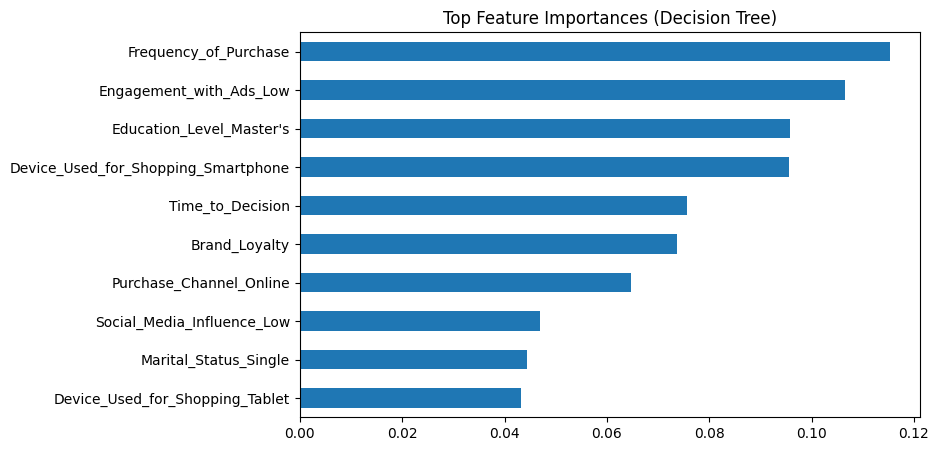

In [38]:
importances.head(10).plot(kind='barh', figsize=(8,5))
plt.title("Top Feature Importances (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()


In [39]:
# Select top N features (configurable)
NUM_TOP_FEATURES = 7
num_available = len(importances)
num_to_select = min(NUM_TOP_FEATURES, num_available)

top_features = importances.head(num_to_select).index.tolist()
X_selected = X[top_features]

print(f"Selected top {num_to_select} features:", top_features)

Selected top 7 features: ['Frequency_of_Purchase', 'Engagement_with_Ads_Low', "Education_Level_Master's", 'Device_Used_for_Shopping_Smartphone', 'Time_to_Decision', 'Brand_Loyalty', 'Purchase_Channel_Online']


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)


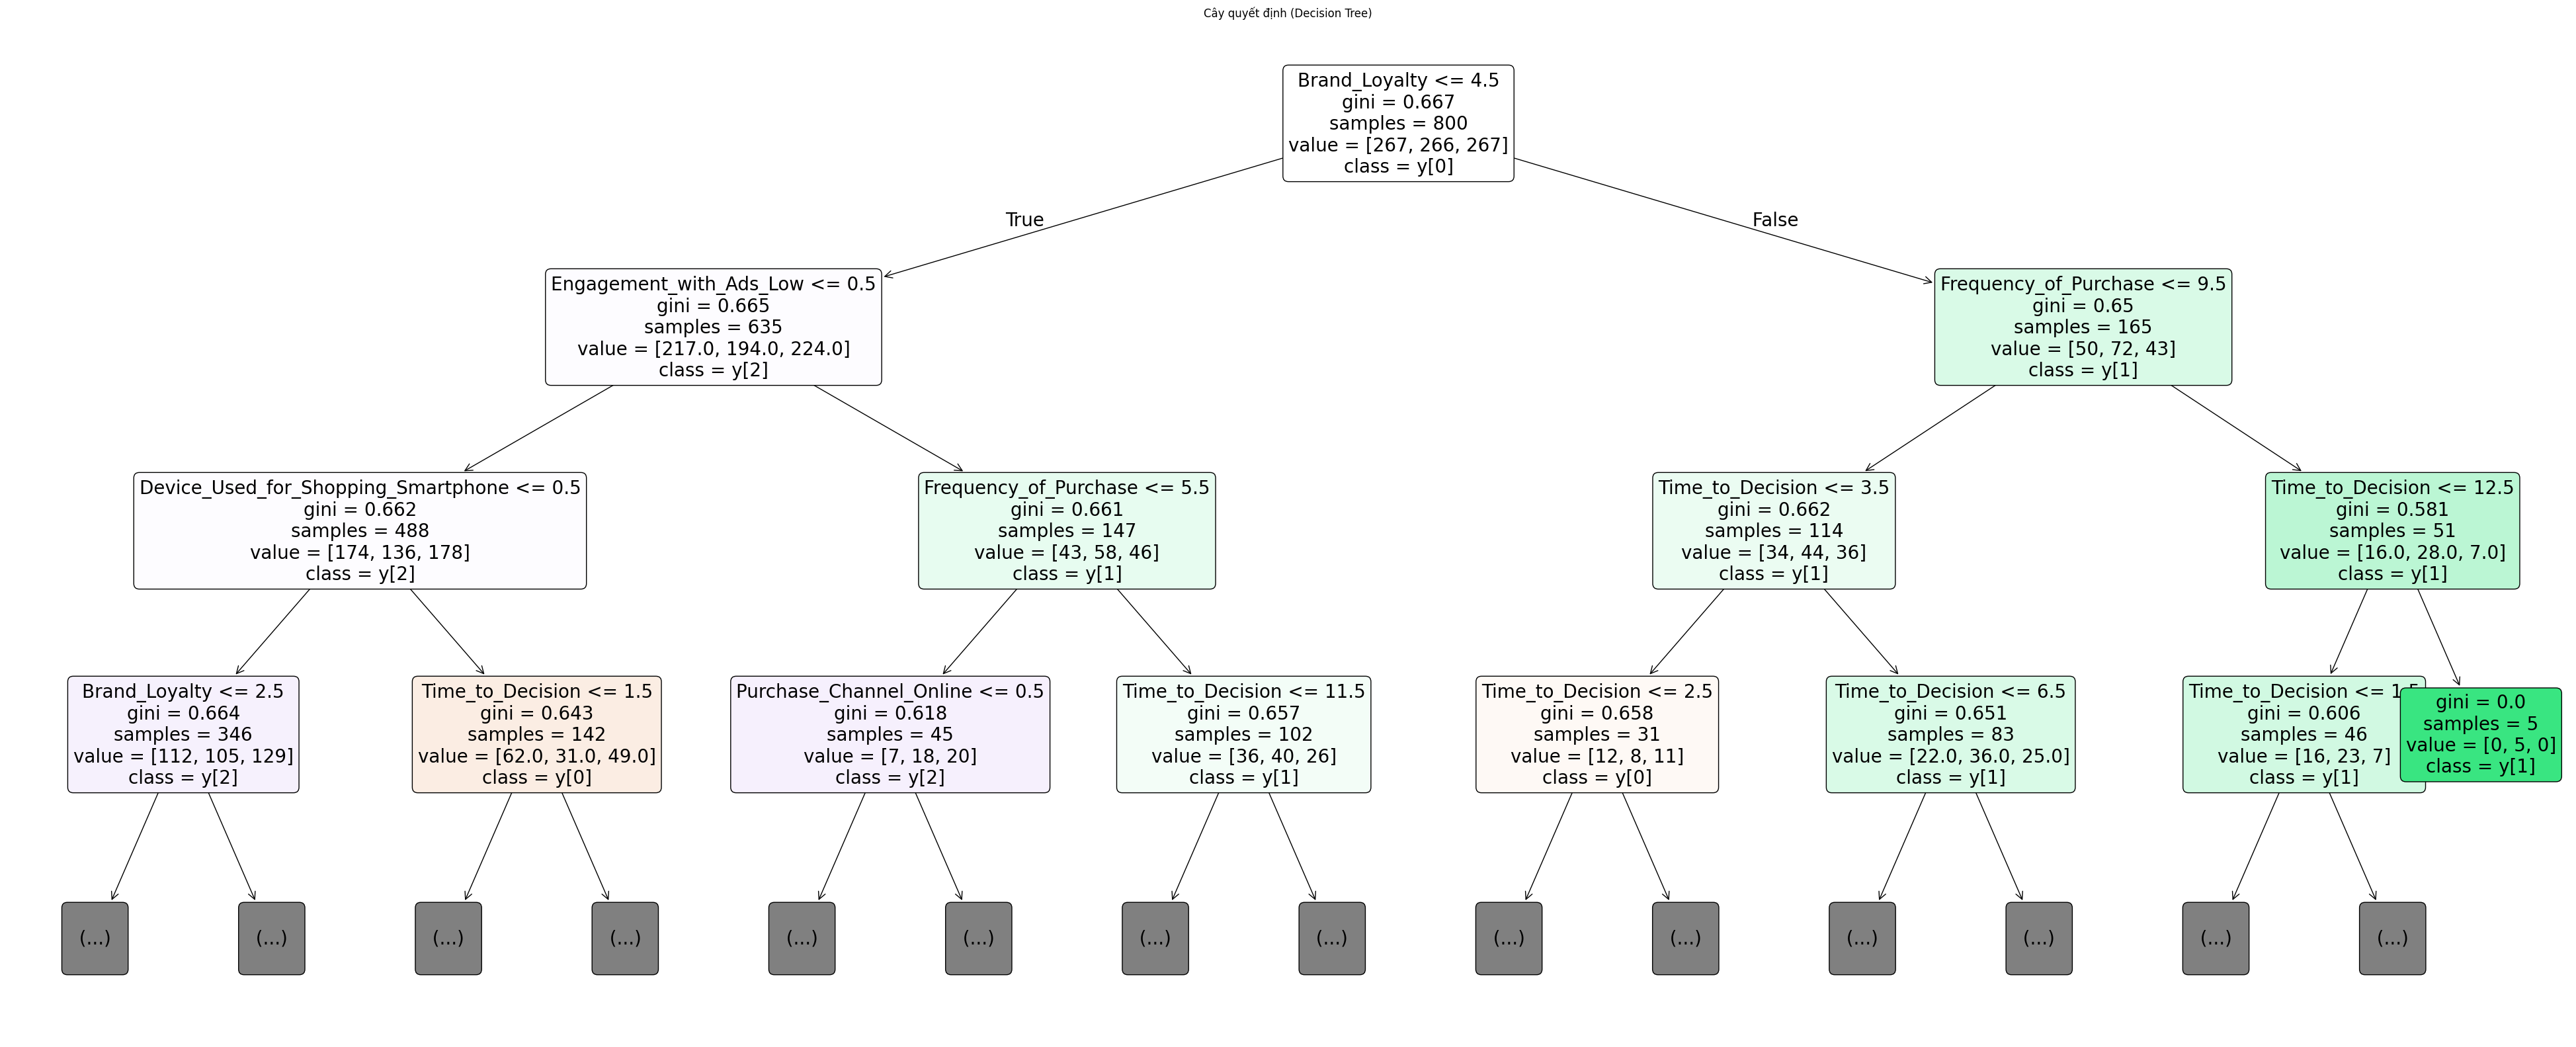

In [41]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(50, 20))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=True,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=20
)
plt.title("Cây quyết định (Decision Tree)")
plt.show()


Accuracy: 0.365
              precision    recall  f1-score   support

           0       0.40      0.34      0.37        67
           1       0.32      0.24      0.27        67
           2       0.37      0.52      0.43        66

    accuracy                           0.36       200
   macro avg       0.36      0.37      0.36       200
weighted avg       0.36      0.36      0.36       200



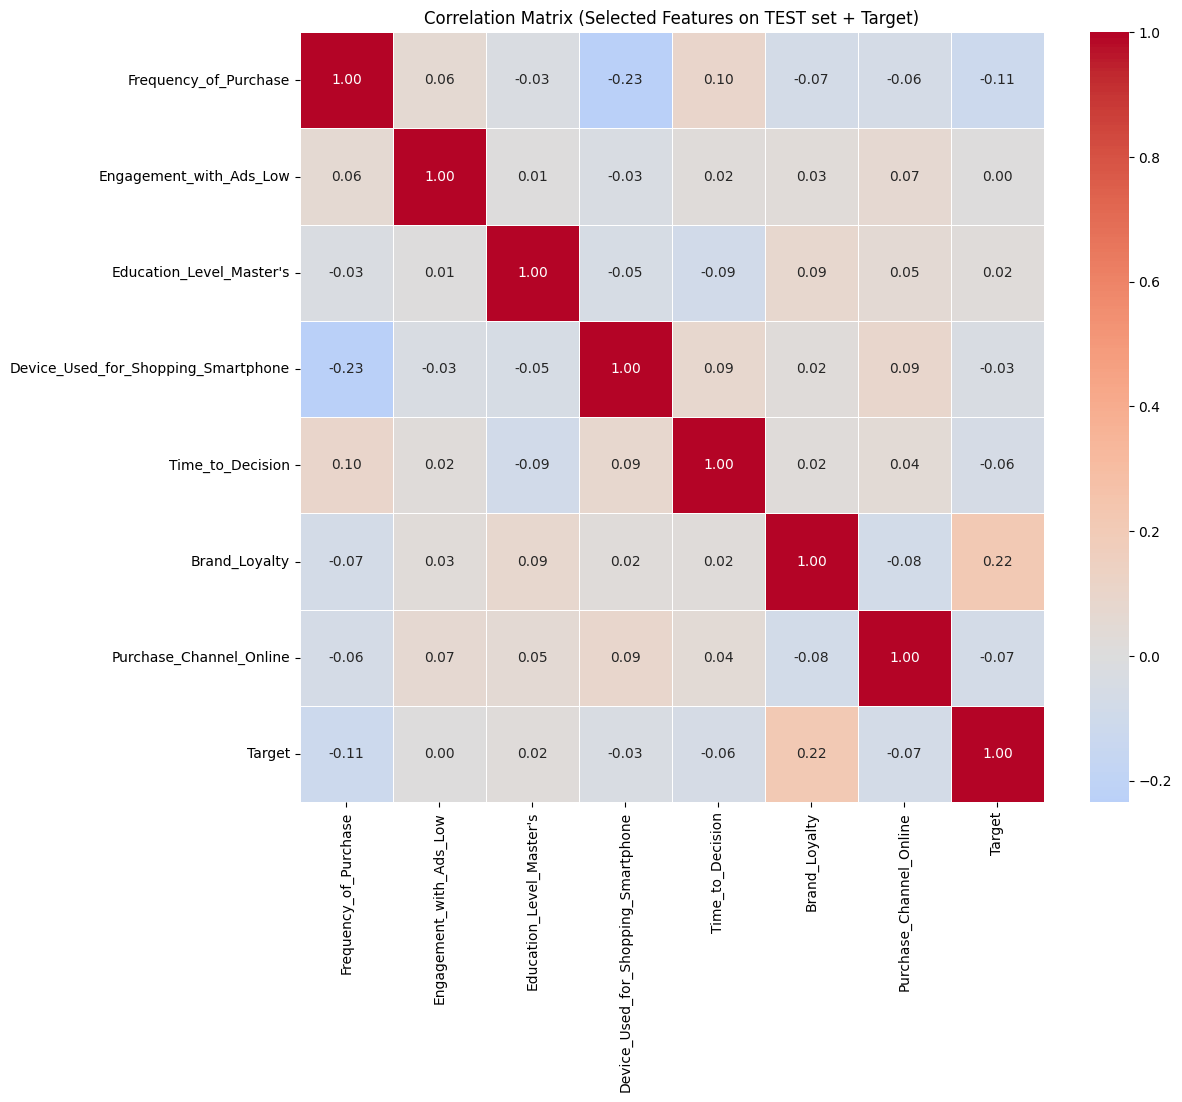

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# --- Correlation heatmap for selected features on the TEST set ---
try:
    # Ensure y_test is a pandas Series with a name
    y_test_series = pd.Series(y_test).reset_index(drop=True)
    y_test_series.name = 'Target'

    corr_df = pd.concat([X_test.reset_index(drop=True), y_test_series], axis=1)

    plt.figure(figsize=(12,10))
    sns.heatmap(
        corr_df.corr(),
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        linewidths=0.5
    )
    plt.title('Correlation Matrix (Selected Features on TEST set + Target)')
    plt.show()
except Exception as e:
    print('Could not plot correlation matrix:', e)


In [43]:
test_result = X_test.copy()
# Convert y_test and y_pred to pandas Series and align indices
y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(y_pred).reset_index(drop=True)

# Reset index of X_test copy to ensure alignment
test_result = test_result.reset_index(drop=True)

test_result['Actual_Spending_Level'] = y_test_series
test_result['Predicted_Spending_Level'] = y_pred_series

test_result.to_csv("spending_level_predictions.csv", index=False)
print("Saved predictions to spending_level_predictions.csv")

Saved predictions to spending_level_predictions.csv


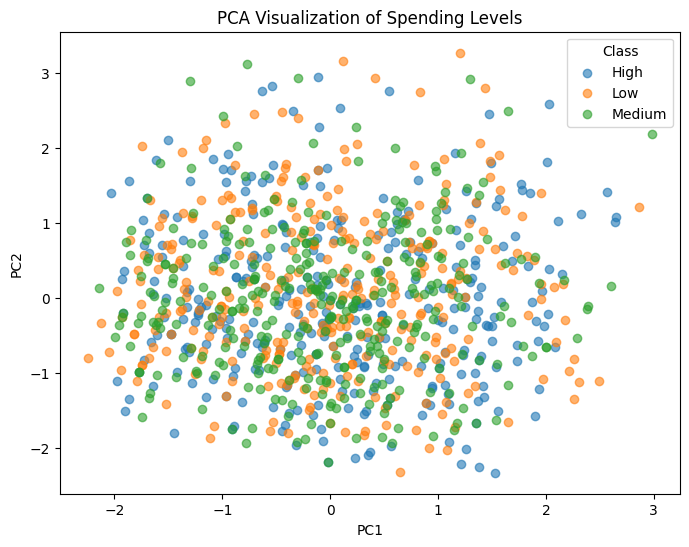

In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Ensure y is a pandas Series (handles numpy arrays)
y_series = pd.Series(y).reset_index(drop=True)

# Try to get human-readable label names if encoder exists
label_values = np.unique(y_series)
try:
    if 'le_target' in globals():
        label_names = le_target.inverse_transform(label_values)
    else:
        label_names = label_values.astype(str)
except Exception:
    label_names = label_values.astype(str)

plt.figure(figsize=(8,6))
palette = sns.color_palette('tab10', n_colors=len(label_values))
for lv, name, color in zip(label_values, label_names, palette):
    mask = (y_series == lv).values
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=str(name),
        alpha=0.6,
        color=color
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Class')
plt.title("PCA Visualization of Spending Levels")
plt.show()
